# Assignment 1: Algorithmic Fairness Definitions

In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from scipy.optimize import minimize
from scipy.optimize import differential_evolution
import numpy as np
import matplotlib.pyplot as plt

This component of the assignment derives in part, with thanks and permission, from an [assignment](https://web.stanford.edu/class/cs182/assignments/AlgorithmicDecisionMaking.zip) in Stanford's CS182: Ethics, Public Policy, and Technological Change. Their assignment, in turn, is based on the journalistic organization ProPublica's [analysis](https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing) of a criminal risk prediction algorithm which we discussed in the algorithmic fairness lecture. Here, you will be assessing how a classifier designed to predict recidivism -- that is, whether someone will commit a crime in the future -- performs in terms of algorithmic fairness metrics.

## Problem 1: Loading the data (10 points)

We have split the data for you into a train set (`recidivism-training-data.csv`) and test set (`recidivism-testing-data.csv`). You will be training the model on the train set and evaluating model predictions on the test set.

1a. Read in the train and test sets. Display the first 10 rows of the data. (4 points)

In [3]:
train_data = pd.read_csv("recidivism-training-data.csv")
train_data.head(10)

,Juvenile felony count = 0,Juvenile felony count = 1,Juvenile felony count = 2,Juvenile felony count >= 3,Juvenile misdemeanor count = 0,Juvenile misdemeanor count = 1,Juvenile misdemeanor count = 2,Juvenile misdemeanor count >= 3,Juvenile other offense count = 0,Juvenile other offense count = 1,...,Age > 45,Gender = Female,Gender = Male,Race = Other,Race = Asian,Race = Native American,Race = Caucasian,Race = Hispanic,Race = African American,recidivism_outcome
0,1,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,1
1,1,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,1
2,1,0,0,0,1,0,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
3,1,0,0,0,1,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0
4,1,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
5,1,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,1,0,0
6,1,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,1
7,0,1,0,0,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,1,1
8,1,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
9,1,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1


In [4]:
test_data = pd.read_csv("recidivism-testing-data.csv")
test_data.head(10)

,Juvenile felony count = 0,Juvenile felony count = 1,Juvenile felony count = 2,Juvenile felony count >= 3,Juvenile misdemeanor count = 0,Juvenile misdemeanor count = 1,Juvenile misdemeanor count = 2,Juvenile misdemeanor count >= 3,Juvenile other offense count = 0,Juvenile other offense count = 1,...,Age > 45,Gender = Female,Gender = Male,Race = Other,Race = Asian,Race = Native American,Race = Caucasian,Race = Hispanic,Race = African American,recidivism_outcome
0,1,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
1,1,0,0,0,1,0,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
2,1,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,0
3,1,0,0,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,1,1
4,1,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,1
5,1,0,0,0,1,0,0,0,1,0,...,0,0,1,1,0,0,0,0,0,0
6,1,0,0,0,1,0,0,0,1,0,...,0,1,0,0,0,0,0,1,0,1
7,1,0,0,0,1,0,0,0,1,0,...,1,1,0,0,0,0,0,0,1,1
8,1,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
9,1,0,0,0,0,1,0,0,1,0,...,0,0,1,0,0,0,0,0,1,1


1b. Read the data documentation in the `Algorithmic Fairness Data Documentation` file. What are the possible values of the `Race` variable in the dataset? (1 point)

#### There are 6 possible values for the Race attribute in the dataset: Other, Asian, Native American, Caucasian, Hispanic, or African-American. In the dataset they are one-hot encoded so each attribute can either take on 0 or 1 within its own Race subgroup column.

1c. Create a histogram of the race and gender distribution using the training dataset (5 points)


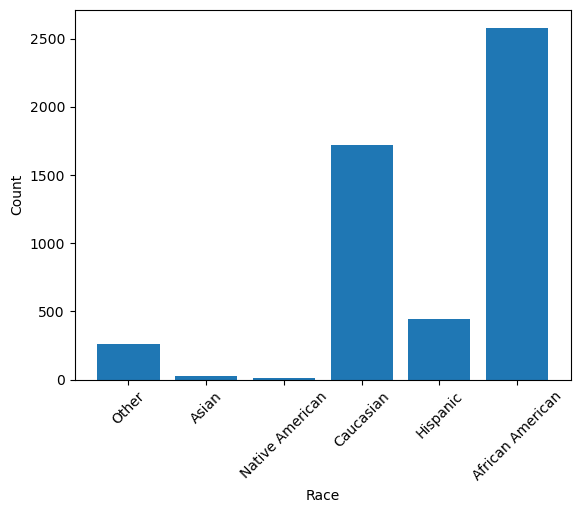

In [5]:
subgroup_race_labels = ["Other", "Asian", "Native American", "Caucasian", "Hispanic", "African American"]
race_labels = [f"Race = {r}" for r in subgroup_race_labels]

bar_vals = [len(train_data[train_data[r]==1]) for r in race_labels]

fig,ax = plt.subplots(1,1)
ax.bar(np.arange(len(bar_vals)), bar_vals)
ax.set_xticks(np.arange(len(bar_vals)), subgroup_race_labels, rotation=45)
ax.set_xlabel("Race")
ax.set_ylabel("Count")
plt.show()

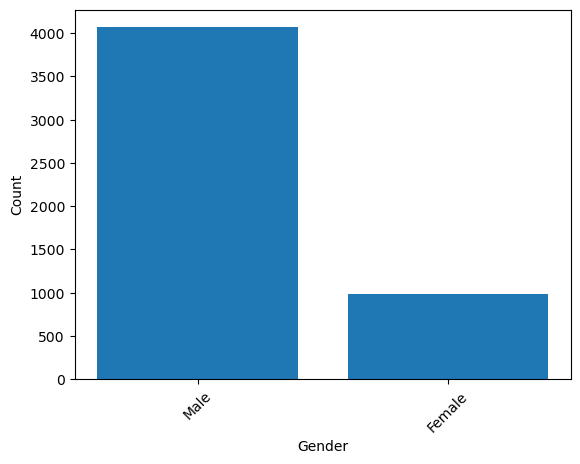

In [6]:
subgroup_gender_labels = ["Male", "Female"]
gender_labels = [f"Gender = {g}" for g in subgroup_gender_labels]

bar_vals = [len(train_data[train_data[g]==1]) for g in gender_labels]

fig,ax = plt.subplots(1,1)
ax.bar(np.arange(len(bar_vals)), bar_vals)
ax.set_xticks(np.arange(len(bar_vals)), subgroup_gender_labels, rotation=45)
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
plt.show()

## Problem 2: Predicting Recidivism with a Full Logistic Regression (20 points)

Now you will use the train set to train a logistic regression model using `sklearn.linear_model.LogisticRegression`. To train a logistic regression model on features X to predict outcome y, you can use the command:

`LogisticRegression(penalty='none').fit(X, y)`

You will have to replace X and y with the data you actually want to use. [Here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) is the documentation on logistic regression. Use the "recidivism_outcome" column as the variable you are trying to predict (y).

Then, we will ask you to report model performance metrics. Use the test set to compute those quantities. You could take a look at helpful functions from the [scikit-learn metrics module](https://scikit-learn.org/stable/modules/model_evaluation.html), imported at the beginning of the assignment as `metrics`.

2a. Train a logistic regression model using all features (except `recidivism_outcome`) as input features X. (5 points)

In [7]:
y_train = np.array(train_data["recidivism_outcome"].tolist())
X_train = train_data.copy().drop(columns=["recidivism_outcome"],inplace=False).to_numpy()

lr = LogisticRegression(penalty=None)
lr.fit(X_train, y_train)


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


2b. Predict recidivism for the test set. Display the first 10 predictions. (1 point)

In [8]:
y_test = np.array(test_data["recidivism_outcome"].tolist())
X_test = test_data.copy().drop(columns=["recidivism_outcome"],inplace=False).to_numpy()

y_preds = lr.predict(X_test)
print(y_preds[:10])

[1 0 1 1 1 0 0 0 0 1]


2c. Report your model's AUC (i) for all defendants, (ii) for white defendants, and (iii) for Black defendants. Report the values with 4 decimal points. (1 point)

In [9]:
w_inds = test_data[test_data["Race = Caucasian"]==1].index
b_inds = test_data[test_data["Race = African American"]==1].index

y_test_w = y_test[w_inds]
y_pred_w = y_preds[w_inds]

y_test_b = y_test[b_inds]
y_pred_b = y_preds[b_inds]

all_auc = metrics.roc_auc_score(y_test, y_preds)
w_auc = metrics.roc_auc_score(y_test_w, y_pred_w)
b_auc = metrics.roc_auc_score(y_test_b, y_pred_b)

print(f"AUC (All): {np.round(all_auc,4)}")
print(f"AUC (White): {np.round(w_auc,4)}")
print(f"AUC (Black): {np.round(b_auc,4)}")

AUC (All): 0.6722
AUC (White): 0.6632
AUC (Black): 0.6564


2d. Report your model's false positive rate (i) for all defendants, (ii) for white defendants, and (iii) for Black defendants. Report the values with 4 decimal points. (1 point)

In [10]:
# false positives / actual negatives -->  fp / fp + tn
def fpr(y_test,y_preds):
    cm = metrics.confusion_matrix(y_test, y_preds)
    fpr = cm[0][1] / (cm[0][1] +  cm[0][0]) 
    return fpr

print(f"FPR (All): {np.round(fpr(y_test, y_preds),4)}")
print(f"FPR (White): {np.round(fpr(y_test_w, y_pred_w),4)}")
print(f"FPR (Black): {np.round(fpr(y_test_b, y_pred_b),4)}")


FPR (All): 0.283
FPR (White): 0.1719
FPR (Black): 0.4165


2e. Report your model's false negative rate (i) for all defendants, (ii) for white defendants, and (iii) for Black defendants. Report the values with 4 decimal points. (1 point)

In [11]:
# false negatives / actual positives --> fn / fn + tp
def fnr(y_test,y_preds):
    cm = metrics.confusion_matrix(y_test, y_preds)
    fnr = cm[1][0] / (cm[1][0] +  cm[1][1]) 
    return fnr

print(f"FNR (All): {np.round(fnr(y_test, y_preds),4)}")
print(f"FNR (White): {np.round(fnr(y_test_w, y_pred_w),4)}")
print(f"FNR (Black): {np.round(fnr(y_test_b, y_pred_b),4)}")

FNR (All): 0.3727
FNR (White): 0.5018
FNR (Black): 0.2707


2f. Report the fraction of defendants classified positive by your model (i) for all defendants, (ii) for white defendants, and (iii) for Black defendants. Report the values with 4 decimal points. (1 point)

In [12]:
# fp + tp / tn + fn + tp + fp
def frac_positive(y_test,y_preds):
    cm = metrics.confusion_matrix(y_test,y_preds)
    frac_positive = (cm[0][1] + cm[1][1]) / (cm[0][0] + cm[1][0] + cm[1][1] + cm[0][1])
    return frac_positive

print(f"Fraction Positive (All): {np.round(frac_positive(y_test, y_preds),4)}")
print(f"Fraction Positive (White): {np.round(frac_positive(y_test_w, y_pred_w),4)}")
print(f"Fraction Positive (Black): {np.round(frac_positive(y_test_b, y_pred_b),4)}")

Fraction Positive (All): 0.4367
Fraction Positive (White): 0.2982
Fraction Positive (Black): 0.5763


2g. In at least 5 sentences, describe what you observe, and any algorithmic fairness concerns it raises, making reference to specific algorithmic fairness concepts discussed in class and using quantitative evidence from 2c-f. Do you believe this algorithm is fair enough to be deployed in practice? Why or why not? (10 points)

#### At first it seems the model is treating all subgroups fairly because the overall AUC is similar (~0.65), but then I noticed that the FPR, FNR, and overall fraction positive are ~2x different for each subgroup. In the case of predicting recidivism, a false positive indicates falsely predicting recidivism, which unnecessarily restricts an individual's freedom and may impact further treatment within the criminal justice system. On the other hand, a false negative indicates missing an actual case of recidivism and thus subjecting society to unnecessary and harmful behavior. The false positive rate for Black people is ~2x higher than White people and false negative rate is ~2x lower for Black people than White people, which suggests that when the model makes mistakes, it is erring on the side of harsher restrictions for Black people than with White people and thus Black people are bearing more of the cost of misclassification. If we are operating under the 'separation' definition of fairness where we expect error rate parity (i.e. FPR and FNR should be equal for all subgroups), then this algorithm is undoubtedly unfair and should not be deployed in practice because it will systematically disadvantage Black people while allowing a worryingly high fraction of White people to recidivate.



## Problem 3: Implementing Equalized Odds (20 points)

Below you're going to implement an equal opportunity algorithm for black and white defendants. Equal opportunity is a specialized case of equalized odds where the true positive rate (tpr) is the same across different sensitive attributes.

Recall that in Problem 2, sklearn's `.predict()` method used a default threshold of 0.5: any predicted probability ≥ 0.5 was classified as positive. However, we can adjust this threshold to change the tradeoff between different types of errors. For example, setting a threshold of 0.7 means only predictions with probability ≥ 0.7 are classified as positive.

Different groups may require different thresholds to achieve fairness. Rather than retraining the model, equal opportunity algorithm adjusts the decision thresholds for each group.


3a. The first step in implementing this algoithm is determining  true positive rate (tpr) for each group. Write a function to determine the tpr for a given threshold. (5 points)

In [13]:
def tpr(y_true, probs, thresh):
    """
    Determine the true positive rate for a given threshold. Any predicted probabilities above the threshold are considered positive (or correct predictions) predictions.
    Args:
        y_true: binary ground truth labels (0/1)
        probs: predicted probabilities for positive class
        thresh: decision threshold
    """
    preds = [1 if prob>=thresh else 0 for prob in probs]
    tp = np.sum([1 if preds[i]==1 and y_true[i]==1 else 0 for i in range(len(preds))])
    fp = np.sum([1 if preds[i]==1 and y_true[i]==0 else 0 for i in range(len(preds))])
    pos = tp + fp
    return tp / pos if pos > 0 else 0.0

3b. Next you will need to determine the accuracy of the predictions. Write a function to determine the accuracy for a given threshold. (5 points)

In [14]:
def accuracy(y_true, probs, thresh):
    """
    Determine the accuracy by calculating the total number of correct prediction over the total predictions.
    Args:
        y_true: binary ground truth labels (0/1)
        probs: predicted probabilities for positive class
        thresh: decision threshold
    """
    preds = [0 if prob < thresh else 1 for prob in probs]
    tp = np.sum([1 if preds[i]==1 and y_true[i]==1 else 0 for i in range(len(preds))])
    tn = np.sum([1 if preds[i]==0 and y_true[i]==0 else 0 for i in range(len(preds))])
    fp = np.sum([1 if preds[i]==1 and y_true[i]==0 else 0 for i in range(len(preds))])
    fn = np.sum([1 if preds[i]==0 and y_true[i]==1 else 0 for i in range(len(preds))])
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    return accuracy

3c. You will then create an objective function to be optimized. The function calculates the average accuracy across both groups and will enforce a penalty if the tpr between the groups isn't approximately equal. Since optimization algorithms typically *minimize* functions, you'll want to minimize the negative of accuracy.

Using the accuracy function from part b, determine the average accuracy (2 points).

Using the tpr function from part a, determine the difference in tpr between the groups to enforce a penalty. (3 points)

In [15]:
def objective(thresh, y_true_0, probs_0, y_true_1, probs_1, penalty_weight=100.0):
    """
    Maximize accuracy with penalty for TPR difference > 0.1

    Args:
        y_true: binary ground truth labels (0/1)
        probs: predicted probabilities for positive class
        threshold: decision threshold
    """

    #intial thresholds
    t0, t1 = thresh

    #accuracy for each group
    acc0 = accuracy(y_true_0, probs_0, t0)
    acc1 = accuracy(y_true_1, probs_1, t1)

    #write a function to calculate the average accuracy
    avg_acc = (acc0 + acc1) / 2

    #determining the tpr for both groups
    tpr0 = tpr(y_true_0, probs_0, t0)
    tpr1 = tpr(y_true_1, probs_1, t1)

    #write a few lines calculate the difference in tpr between the groups. Enforce a strict sqaured penalty based on the tpr_diff
    tpr_diff = tpr0 - tpr1
    penalty = penalty_weight * tpr_diff**2

    return -avg_acc + penalty

3d. Run the optimization function to determine the new threshold. Then apply the new thresholds to calculate the new predictions based on the equal opportunity algorithm. (2 points)

In [16]:
# probability scores
y_test_probs = lr.predict_proba(X_test)
y_test_probs_w = y_test_probs[w_inds][:, 1]
y_test_probs_b = y_test_probs[b_inds][:, 1]

In [17]:
#intial thresholds
x0 = np.array([0.3, 0.7])

bounds = [(0, 1), (0, 1)]

#optimizing the objective function (applying parts a to c)
res = differential_evolution(
    objective,
    bounds,
    args=(y_test_w, y_test_probs_w, y_test_b, y_test_probs_b),
    seed=42,
    maxiter=1000
)

# new thresholds
t0_opt, t1_opt = res.x

#based on the new thresholds, determine the new predictions. Recall that all probabilities greater than the threshold are considered positive (correct) predictions
y_pred_0_eo = [1 if prob >= t0_opt else 0 for prob in y_test_probs_w]
y_pred_1_eo = [1 if prob >= t1_opt else 0 for prob in y_test_probs_b]

3f. Report the new tpr for both black and white defendants using the adjusted predictions. (3 points)

In [18]:
w_tpr = tpr(y_test_w, y_test_probs_w, t0_opt)
b_tpr = tpr(y_test_b, y_test_probs_b, t1_opt)

print(f"TPR (White): {np.round(w_tpr, 4)}")
print(f"TPR (Black): {np.round(b_tpr, 4)}")

TPR (White): 0.6633
TPR (Black): 0.6638


In [ ]:
def equal_opportunity(model, X_test, w_inds, b_inds):
    # preds and probability scores by group
    y_test_probs = model.predict_proba(X_test)
    y_test_w = y_test[w_inds]
    y_test_probs_w = y_test_probs[w_inds][:, 1]
    y_test_b = y_test[b_inds]
    y_test_probs_b = y_test_probs[b_inds][:, 1]

    #intial thresholds
    x0 = np.array([0.3, 0.7])

    bounds = [(0, 1), (0, 1)]

    #optimizing the objective function (applying parts a to c)
    res = differential_evolution(
        objective,
        bounds,
        args=(y_test_w, y_test_probs_w, y_test_b, y_test_probs_b),
        seed=42,
        maxiter=1000
    )

    # new thresholds
    t0_opt, t1_opt = res.x

    #based on the new thresholds, determine the new predictions. Recall that all probabilities greater than the threshold are considered positive (correct) predictions
    y_pred_0_eo = [1 if prob >= t0_opt else 0 for prob in y_test_probs_w]
    y_pred_1_eo = [1 if prob >= t1_opt else 0 for prob in y_test_probs_b]

    # tpr
    w_tpr = tpr(y_test_w, y_test_probs_w, t0_opt)
    b_tpr = tpr(y_test_b, y_test_probs_b, t1_opt)
    all_tpr = metrics.recall_score(y_test, model.predict(X_test))

    print(f"TPR (All): {all_tpr}")
    print(f"TPR (White): {w_tpr}")
    print(f"TPR (Black): {b_tpr}")

    return t0_opt, t1_opt

## Problem 4: Plotting Calibration (15 points)

Calibration is when for a given risk score, the probability of the outcome is the same for all groups (e.g., if the model is well calibrated, for all defendants who received a score of 0.7, roughly 70% should actually have that outcome, regardless of race). Using the predicted values, and the true positives for black and white defendants, graph the calibration.  (15 points)

Below is a skeleton for the `plot_calibration_histogram` function. The function uses the ground truth labels (y-axis) and the predicted probabilities (x-axis) as parameters.


Fill in code to group the predicted probabilities and ground truth into bins with 0.1 increments. (5 points)

Using the bins, write the code for the relability curve. (5 points)





In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_calibration_histogram(y_true, probs, n_bins=10, group_label=None, ax=None):
    """
    Plots a calibration (reliability diagram).

    Args:
        y_true: binary ground truth labels (0/1)
        probs: predicted probabilities for positive class
        n_bins: number of bins (default=10)
        group_label: optional string label for legend
        ax: optional matplotlib axis
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    # Bin the predicted probabilities
    bin_width = 1.0/n_bins
    bins = [i*bin_width for i in range(n_bins)]
    binned_probs = np.digitize(probs, bins)

    # calculate empirical fraction positive
    frac_pos = []
    for i in range(n_bins):
        curr_inds_bin = np.where(binned_probs==i)[0]
        curr_frac_pos = y_true[curr_inds_bin].sum() / len(curr_inds_bin)
        frac_pos.append(curr_frac_pos)

    # Plot perfect calibration line
    ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")

    # Plot reliability curve
    ax.plot(bins,frac_pos, label=group_label)
    ax.scatter(bins,frac_pos)

    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Empirical positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=":", alpha=0.7)
    if group_label:
        ax.legend()
    return ax

Replace `FILL_IN_HERE` in the code below with the appropriate parameters to plot the calibration curve for black and white defendants. (5 points)

/var/folders/pr/0jl9zy5j5nvcs0ycl3xdjjmm0000gn/T/ipykernel_61218/2140749690.py:27: RuntimeWarning: invalid value encountered in scalar divide
  curr_frac_pos = y_true[curr_inds_bin].sum() / len(curr_inds_bin)


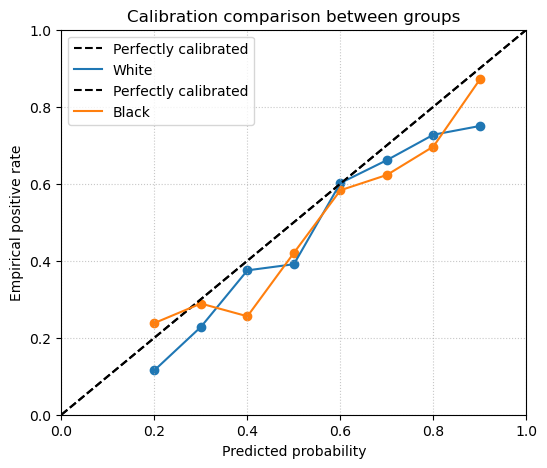

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_calibration_histogram(y_test_w, y_test_probs_w, n_bins=10, group_label="White", ax=ax)
plot_calibration_histogram(y_test_b, y_test_probs_b, n_bins=10, group_label="Black", ax=ax)
plt.title("Calibration comparison between groups")
plt.show()

## Problem 5: Predicting Recidivism with Your Own Model (15 points)

Now you will train your own model to predict recidivism.

5a. Train a model of your choice. You can choose any input features that should be used as well as any pre-processing technique. You are welcome to use models which are not logistic regression models, but if you want to use logistic regression, that's also fine! (2 points)

In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

# hyperparams
dummy_grid = {
    "strategy": ["most_frequent"]
}
lr_param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "penalty":["l1","l2",None]
}
dt_param_grid = {
    "max_depth": [None, 2, 5],
    "max_features": [None, "sqrt"]
}
rf_param_grid = {
    "n_estimators": [2,5,10,100],
    "max_depth":[None, 2, 5],
    "max_features": [None, "sqrt"]
}

# models
dummy = DummyClassifier()
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

# loop through
models = [dummy, lr, dt, rf]
param_grids = [dummy_grid, lr_param_grid, dt_param_grid, rf_param_grid]
results = []

for m,pg in zip(models,param_grids):
    gscv = GridSearchCV(
        m, 
        pg, 
        scoring=["roc_auc"],
        refit=False,
        return_train_score=True
    )
    gscv.fit(X_train, y_train)
    results.append(gscv.cv_results_)

/opt/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/opt/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/opt/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/opt/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/opt/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/opt/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_mo

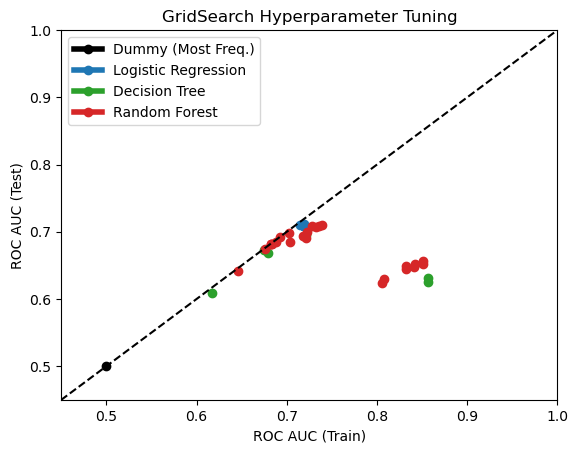

In [ ]:
from matplotlib.lines import Line2D

colors = ["black", "tab:blue","tab:green","tab:red"]
custom_lines = [Line2D([0], [0], color=c, lw=4, marker='o') for c in colors]

fig,ax = plt.subplots(1,1)
for res,c in zip(results,colors):
    ax.scatter(res["mean_train_roc_auc"], res["mean_test_roc_auc"],c=c)
ax.plot([0, 1], [0,1],ls="--",c="k")
ax.set_ylim([0.45,1])
ax.set_xlim([0.45,1])
ax.legend(
    custom_lines, 
    ["Dummy (Most Freq.)", "Logistic Regression", "Decision Tree", "Random Forest"]
)
ax.set_xlabel("ROC AUC (Train)")
ax.set_ylabel("ROC AUC (Test)")
ax.set_title("GridSearch Hyperparameter Tuning")
plt.show()

5b. Report the model's performance on (i) all, (ii) white, and (iii) Black defendants, using whatever metrics you believe are appropriate (at least 2). You are also welcome to evaluate performance on other sensitive/protected groups. (4 points)

In [88]:
print("Top performing interpretable model: ", results[1]["params"][4])
top_params = results[1]["params"][4]
lr = LogisticRegression(**top_params)
lr.fit(X_train, y_train)
y_preds = lr.predict(X_test)

roc_auc_all = metrics.roc_auc_score(y_test, y_preds)
roc_auc_w = metrics.roc_auc_score(y_test[w_inds], lr.predict(X_test[w_inds]))
roc_auc_b = metrics.roc_auc_score(y_test[b_inds], lr.predict(X_test[b_inds]))

print("\nROC AUC Score: \n")
print(f"ROC AUC (All): {roc_auc_all}")
print(f"ROC AUC (White): {roc_auc_w}")
print(f"ROC AUC (Black): {roc_auc_b}")

tpr_all = metrics.recall_score(y_test,y_preds)
tpr_w = metrics.recall_score(y_test[w_inds], lr.predict(X_test[w_inds]))
tpr_b = metrics.recall_score(y_test[b_inds], lr.predict(X_test[b_inds]))

print("\nTPR (before Equal Opp.): \n")
print(f"TPR (All): {tpr_all}")
print(f"TPR(White): {tpr_w}")
print(f"TPR (Black): {tpr_b}")

Top performing interpretable model:  {'C': 0.1, 'penalty': 'l2'}

ROC AUC Score: 

ROC AUC (All): 0.6730135111313889
ROC AUC (White): 0.6591801804644118
ROC AUC (Black): 0.6582528498411828

TPR (before Equal Opp.): 

TPR (All): 0.6273291925465838
TPR(White): 0.49469964664310956
TPR (Black): 0.7293497363796133


In [ ]:
print("Equal Opportunity: \n")
t0_opt, t1_opt = equal_opportunity(lr, X_test, w_inds, b_inds)

Equal Opportunity: 

TPR (All): 0.6273291925465838
TPR (White): 0.665
TPR (Black): 0.6649122807017543


5c. Write two paragraphs defending your model design choices, and explaining why you designed the model the way you did. Refer to results from 3b to provide evidence. You're welcome to write two paragraphs explaining why you don't think models should be used in criminal risk prediction at all - this is a reasonable perspective! - but you still need to provide quantitative or non-quantitative evidence to back up your claims. (9 points)

#### First, I tested hyperparameter combinations of a few different model types (Logistic Regression, Decision Tree, Random Forest) varying in complexity and interpretability, as well as a Dummy Classifier that always predicts the most frequent class label, to get a broad sense of the predictive ability. I chose AUC ROC and TPR as the metric here because they are commonly used baseline evaluation metrics to judge the model's performance before our fairness intervention. The ML approaches performed better than the baseline dummy model (~0.5), with a a range of performances (~0.6 - 0.7) for the well-fit models, and some models overfitting. I did not see any meaningful benefit in using a more complex model (i.e. Random Forest) over the simpler, more interpretable Logistic Regression, which leads me to believe that without extensive feature engineering methods, I am at the upper limit of predictive ability with the information in this dataset for the purposes of this project.

#### We can see that the TPR is much higher for Black defendants than White defendants, as in our earlier unpenalized Logistic Regression model. I chose the highest performing interpretable model (Logistic Regression with Ridge regularization), retrained it, and assessed its performance using equal opportunity. Equal opportunity optimizes the decision threshold to ensure that the model's performance across subgroups with respect to the positive class is equal [5]. This metric aims to ensure that the model is performing equally well for both subgroups. In the case of criminal recidivism, we may be more interested in ensuring equality of positive predictions, and not all types of predictions, because mistakes there correspond to harsher restrictions on individual freedoms. Because this metric is used to make decisions about subgroups differently, it is related to the middle view of equality of opportunity, or the view that decision makers have an obligation to avoid perpetuating injustice by treating seemingly dissimilar people similarly. In this case I believe that this approach is justified because it attempts to mitigate that historical disadvantage that the criminal justice system has had on Black people through such practices as police brutality, racially targeted policing, more punitive prison sentences, and the downstream reverberating impacts of interaction with the criminal justice system [4].

####  The promise of automated recidivism prediction systems is two-fold: better predictive ability than humans currently achieve to reduce the burden of crime on society, and the opportunity to systematize fairness in software so as to avoid human subjectivity and implicit bias. However, while humans aren't particularly good at predicting recidivism, the current machine learning-based approaches do not outstrip human decision makers' predictive ability enough to provide a clear benefit to society [2]. Additionally, as we've seen from the ProPublica study[3], there is a challenging amount of risk and subjectivity in choosing the right algorithmic fairness approaches, as well as difficulty in embedding them into existing institutions in such a way that their predictions are not misused.  So I argue that criminal recidivism prediction is currently a domain that we should not currently look to machine learning for improvement until there is more substantial progress on the foundational understanding of the sociological mechanisms at play, as well as a demonstration of predictive ability that is meaningfully better and fairer in practice than human decision makers.

# Sources cited

Please cite any sources used to complete this homework in the markdown cell below. Nobody remembers everything, and it's always a good idea to use documentation and online resources to ensure you're growing your skills.

Note that copying text from generative AI technology, such as ChatGPT, will be considered plagiarism (and hence result in a 0 grade on this submission). You are allowed to use ChatGPT as a general educational resource (the same way you would a webpage, without copying from it). But if you used ChatGPT as an educational resource, you must include (a) your prompts, (b) ChatGPT's responses, and (c) your validation of why ChatGPT's response is correct; simply noting that the code makes sense does not suffice as an explanation.

#### Citations
1) sklearn documentation
2) Dressel, Julia & Farid, Hany. (2018). The accuracy, fairness, and limits of predicting recidivism. Science Advances. doi: 10.1126/sciadv.aao5580
3) J. Angwin, J. Larson, S. Mattu, L. Kirchner, “Machine bias: There’s software used across the country to predict future criminals. And it’s biased against blacks,” ProPublica, 23 May 2016; www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing.
4) Criminal Justice Fact Sheet. NAACP. https://naacp.org/resources/criminal-justice-fact-sheet
5) Common fairness metrics. Fairlearn. https://fairlearn.org/main/user_guide/assessment/common_fairness_metrics.html